In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


In [2]:
def comparar_imagenes(img_1, img_2, titulo_original="Original", titulo_filtrada="Filtrada"):
    fig, axs = plt.subplots(1,2, figsize=(10,5))
    
    # Original
    axs[0].imshow(img_1, cmap="gray")
    axs[0].set_title(titulo_original)
    axs[0].axis("off")
    
    # Máscara difusa - Fijar vmin=0 para que el fondo (0) sea NEGRO
    # Los valores negativos se verán negros también
    axs[1].imshow(img_2, cmap="gray", vmin=0, vmax=255)
    axs[1].set_title(titulo_filtrada)
    axs[1].axis("off")
    
    plt.tight_layout()
    plt.show()
    
def highboost_interact(img, kernel_size, A):

    img_float = img.astype(np.float32)

        # filtro pasa-bajos
    mask = np.ones((kernel_size, kernel_size), np.float32) / (kernel_size**2)
    img_pb = cv2.filter2D(img_float, -1, mask)

        # high-boost
    highboost = A * img_float - img_pb

        # clipping
    highboost = np.clip(highboost, 0, 255).astype(np.uint8)

    comparar_imagenes(
        img,
        highboost,
        "Original",
        f"HighBoost A={A:.1f} Kernel={kernel_size}x{kernel_size}"
    )

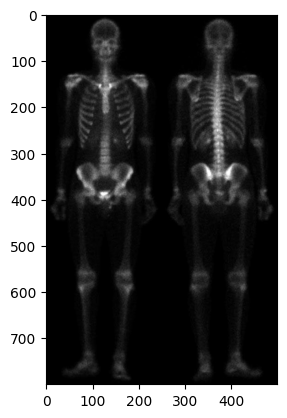

In [3]:
img = cv2.imread("../Imagenes_cursado/esqueleto.tif", cv2.IMREAD_GRAYSCALE)
plt.imshow(img, cmap="gray")

# parte 1: Realce
podemos hacer de dos formas por el momento:
- Utilizando una mascara de realce
- Ecualizando el histogramas
- Alta potencia?)

## Mascara de realce
La mascara debe ser suma uno con valores negativos.

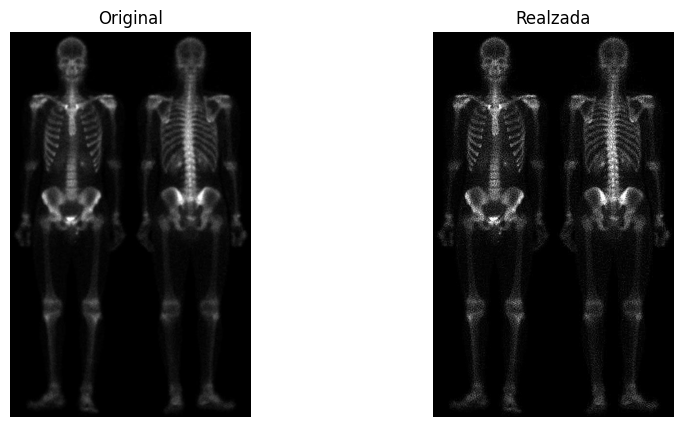

In [4]:
kernel_realce = np.array([
    [ 0, -2,  0],
    [-2,  9, -2],
    [ 0, -2,  0]
], dtype=np.float32)

img_realzada = cv2.filter2D(img, -1, kernel_realce)


plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(img, cmap='gray')
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(img_realzada, cmap='gray')
plt.title("Realzada")
plt.axis("off")

plt.show()

## ecualizando el histograma

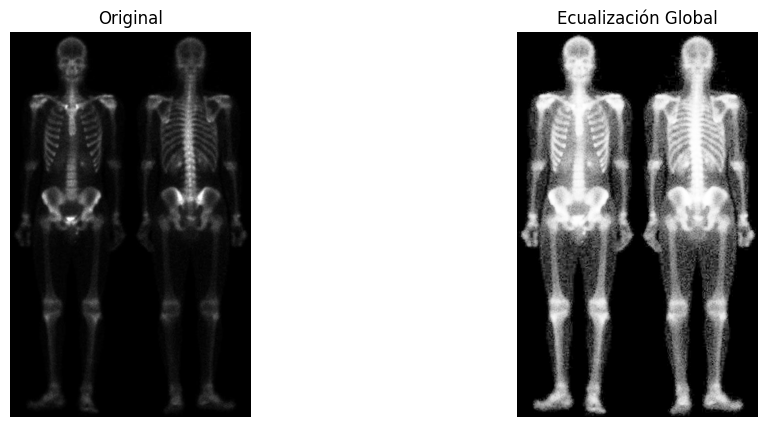

In [5]:
img_eq = cv2.equalizeHist(img)

# Mostrar resultados
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(img, cmap='gray')
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(img_eq, cmap='gray')
plt.title("Ecualización Global")
plt.axis("off")

plt.show()

## highboost

In [ ]:
from ipywidgets import interact, IntSlider, FloatSlider
import ipywidgets as widgets

interact(
    lambda kernel_size, A: highboost_interact(img, kernel_size, A),

    kernel_size=IntSlider(
        value=5,
        min=3,
        max=15,
        step=2,
        description="Kernel"
    ),

    A=FloatSlider(
        value=1.0,
        min=0.1,
        max=5.0,
        step=0.1,
        description="A"
    )
)

interactive(children=(IntSlider(value=5, description='Kernel', max=15, min=3, step=2), FloatSlider(value=1.0, …

<function __main__.<lambda>(kernel_size, A)>

EL filtrado de alta potencia pareciera tener mejores resultados

# parte 2: 

Imagen cargada: mariposa02.png -> shape (601, 799)
Imagen cargada: flores02.jpg -> shape (533, 800)
Imagen cargada: lapices02.jpg -> shape (762, 1024)


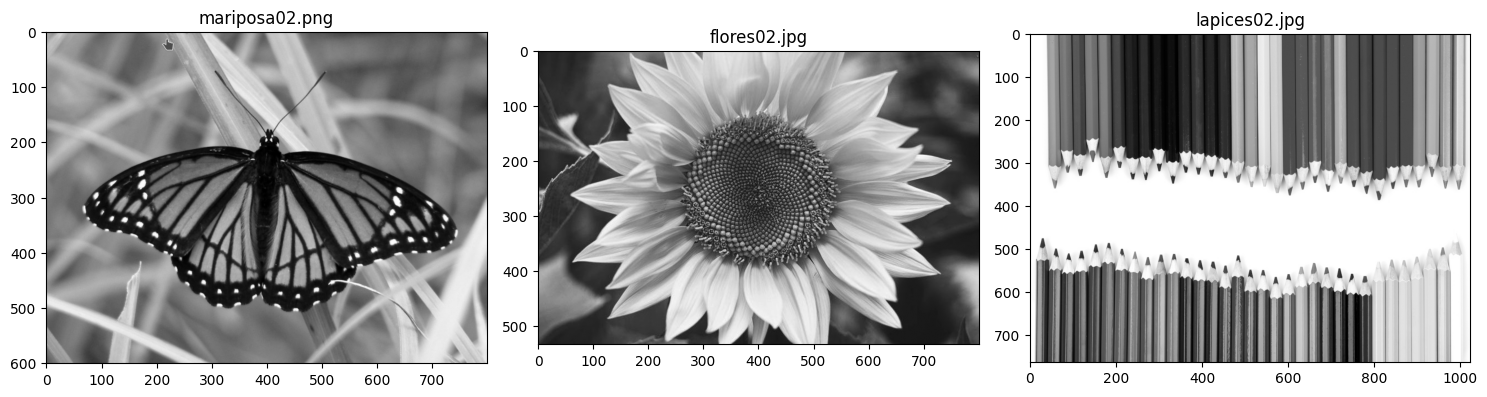

In [7]:
nombres = [
    "mariposa02.png",
    "flores02.jpg",
    "lapices02.jpg"
]

imagenes = {}
for nombre in nombres:

    ruta = f"../Imagenes_cursado/{nombre}"
    img = cv2.imread(ruta, cv2.IMREAD_GRAYSCALE)

    imagenes[nombre] = img
    print(f"Imagen cargada: {nombre} -> shape {img.shape}")

plt.figure(figsize=(15,5))

for i, (nombre, img) in enumerate(imagenes.items()):

    plt.subplot(1, len(imagenes), i+1)
    plt.imshow(img, cmap='gray')
    plt.title(nombre)


plt.tight_layout()
plt.show()

In [8]:
def perfil_grises(img, indice, eje='fila'):

    if eje == 'fila':
        perfil = img[indice, :]
    elif eje == 'columna':
        perfil = img[:, indice]

    else:
        raise ValueError("eje debe ser 'fila' o 'columna'")
    return perfil



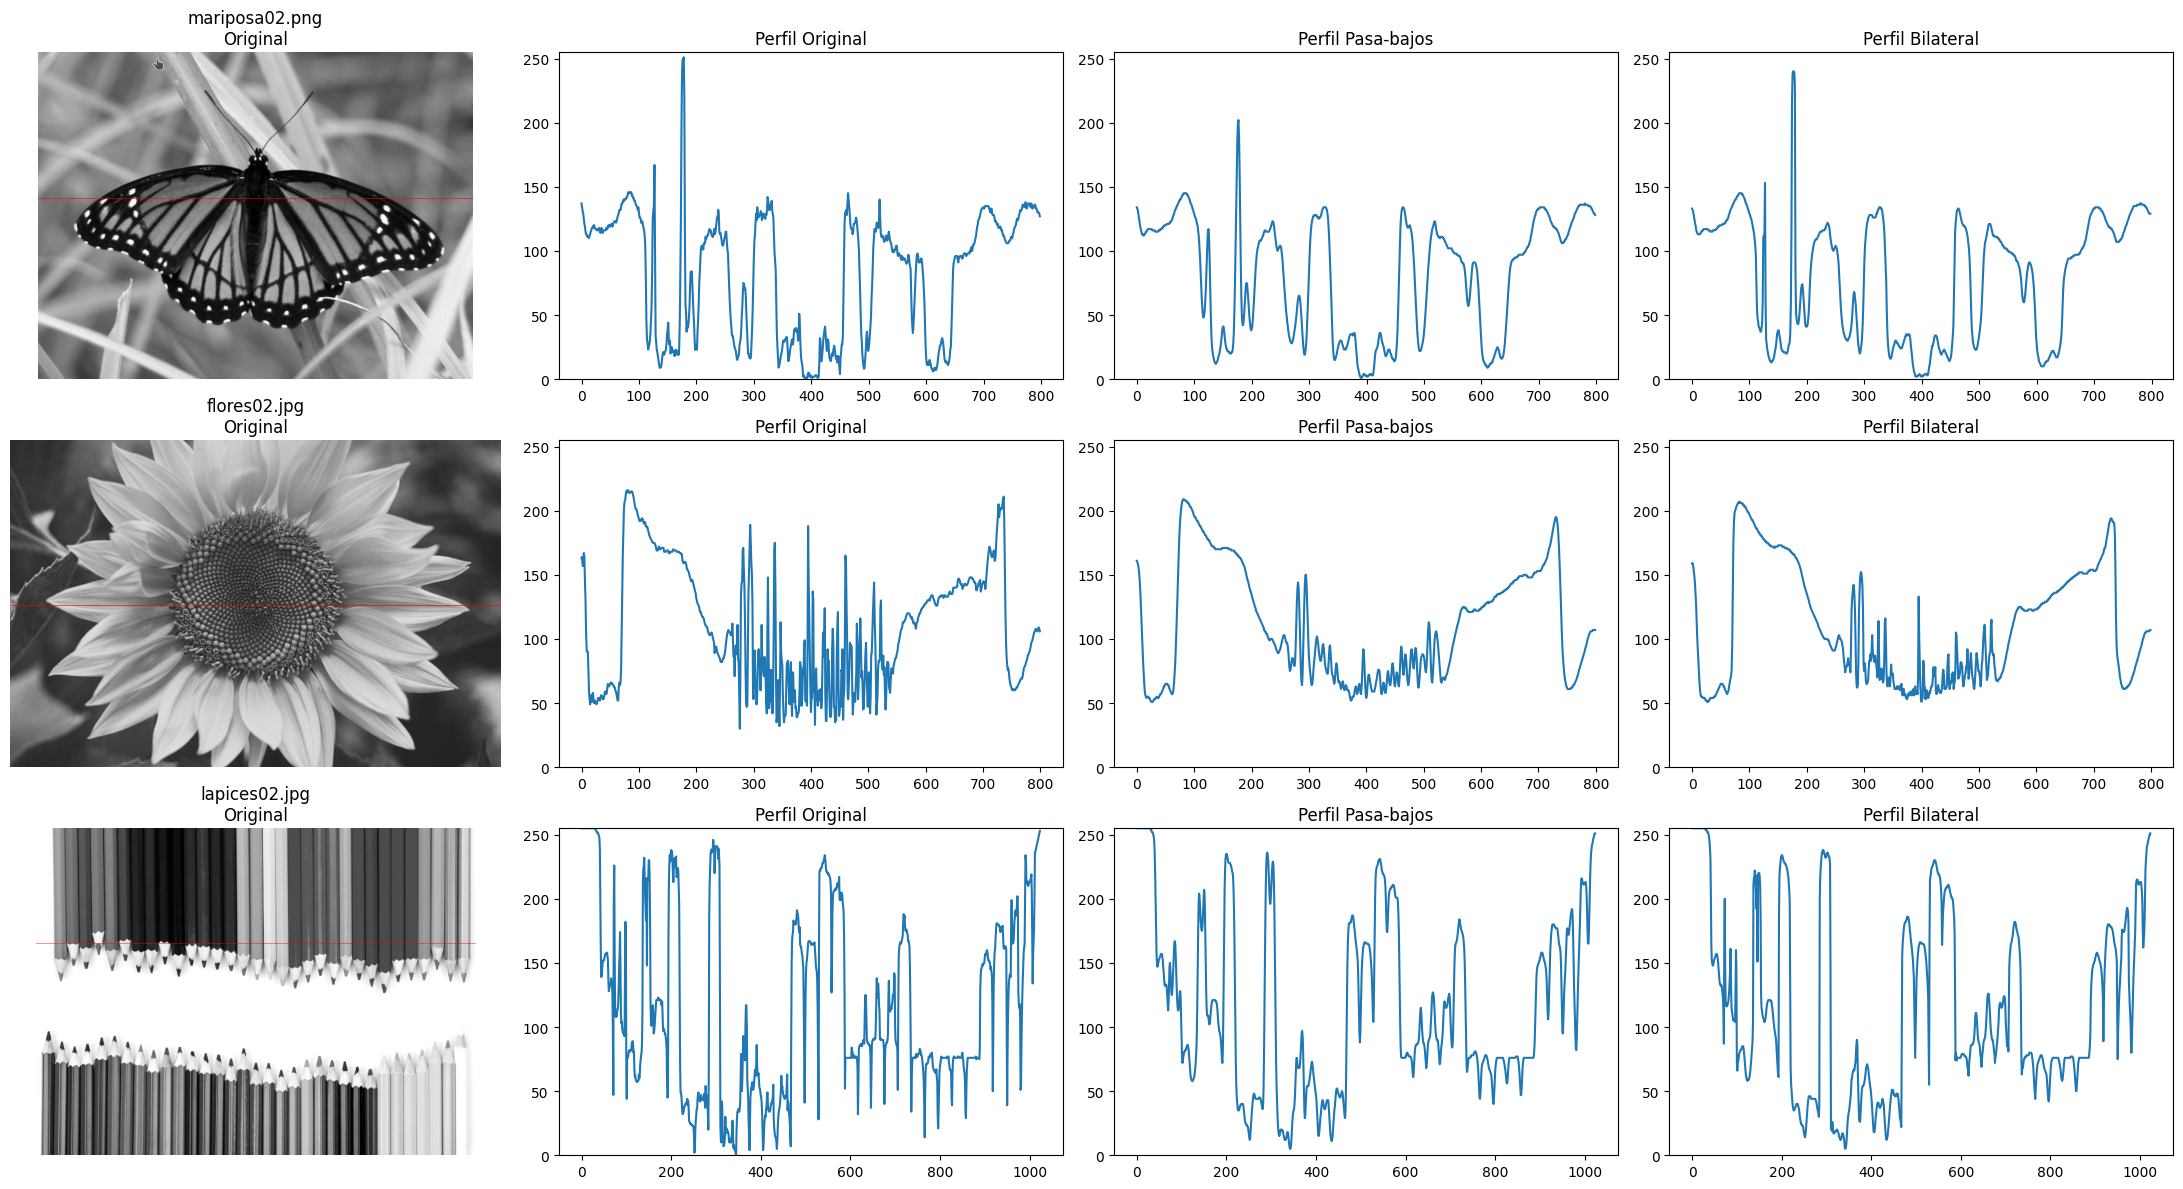

In [9]:
nombres = [
    "mariposa02.png",
    "flores02.jpg",
    "lapices02.jpg"
]

indice = 270      # fila o columna seleccionada
eje = 'fila'      # 'fila' o 'columna'


fig, axs = plt.subplots(len(nombres), 4, figsize=(22, 12))
for i, nombre in enumerate(nombres):
    ruta = f"../Imagenes_cursado/{nombre}"
    img = cv2.imread(ruta, cv2.IMREAD_GRAYSCALE)

    img_pb = cv2.GaussianBlur(img, (9,9), 0)
    img_bilateral = cv2.bilateralFilter(
        img,
        d=9,
        sigmaColor=50,
        sigmaSpace=50
    )

    perfil_original = perfil_grises(img, indice, eje)
    perfil_pb = perfil_grises(img_pb, indice, eje)
    perfil_bilateral = perfil_grises(img_bilateral, indice, eje)

    img_linea = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
    if eje == 'fila':
        img_linea[indice, :, :] = [255, 0, 0]
    else:
        img_linea[:, indice, :] = [255, 0, 0]

    axs[i,0].imshow(img_linea)
    axs[i,0].set_title(f"{nombre}\nOriginal")
    axs[i,0].axis("off")



    axs[i,1].plot(perfil_original)
    axs[i,1].set_title("Perfil Original")
    axs[i,1].set_ylim([0,255])


    axs[i,2].plot(perfil_pb)
    axs[i,2].set_title("Perfil Pasa-bajos")
    axs[i,2].set_ylim([0,255])

    axs[i,3].plot(perfil_bilateral)
    axs[i,3].set_title("Perfil Bilateral")
    axs[i,3].set_ylim([0,255])

plt.tight_layout()
plt.show()

Se ven como poco a poco se atenuan las frecuencias. Mas que nadas en los primeros dos casos